In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV

from pickle import dump

import mlacca_functions as mlcf

In [ ]:
df_path = 'data\\csv_files\\new_vk_areas_df.csv'
df_with_pahs_path = 'data\\csv_files\\new_vk_areas_with_pahs.csv'

decision_boundaries_output_folder = 'data\\plots\\decision_boundaries'
models_output_folder = 'data\\models'

weighted = True
show_title = False

In [ ]:
df = pd.read_csv(df_path)

In [ ]:
def pickle_model(clf, filepath):
    with open(filepath, "wb") as f:
        dump(clf, f, protocol=5)


def create_3D_mesh(data, model, dims, number_of_points=50) -> pd.DataFrame:
    # https://www.kaggle.com/code/frankmollard/3d-decision-boundaries
    '''
    Create a 3D meshgrid for decision boundary visualization.
    '''
    data=data.copy()
    meshes_2d={}
    for i in range(len(dims)):
        meshes_2d.update({f"{dims[i]}": np.linspace(np.min(data[:,i]), np.max(data[:,i]), number_of_points)})

    # create meshgrid
    meshes_3d = np.meshgrid(*[x for x in meshes_2d.values()],
                            indexing='ij')

    stacked_mesh = np.vstack([x.ravel() for x in meshes_3d]).T  

    mesh_df = pd.DataFrame(stacked_mesh, columns=dims)

    preds = model.predict_proba(stacked_mesh)
    argmax = np.argmax(preds, axis=1)

    highest_probs = np.max(preds, axis=1)

    mesh_df['category'] = model.classes_[argmax]
    mesh_df['probability'] = highest_probs

    return mesh_df.sort_values(by=['category']).reset_index(drop=True)


def create_fig_for_3d_decision_boundary(mesh_df:pd.DataFrame, title:str=None, dims:list=None, alpha=.8, squareSize=10, colours=None) -> go.Figure:
    vizList = []
    for compound_class in mesh_df['category'].unique():

        i = mesh_df['category'] == compound_class

        compound_class_formatted = compound_class.capitalize().replace('Pah', 'PAH').replace('_',' ')

        globals()[f"D_{compound_class}"]=go.Scatter3d(

            x = mesh_df.loc[i, dims[0]],
            y = mesh_df.loc[i, dims[1]],
            z = mesh_df.loc[i, dims[2]],

            name = f"{compound_class_formatted}-like",

            hovertemplate = dims[0] + ': %{x} <br>' + \
                            dims[1] + ': %{y} <br>' + \
                            dims[2] + ': %{z} <br>',
                            # 'category: {0} <br>'.format(compound_class_formatted),

            mode='markers',
            marker=dict(
                size=squareSize,
                color=colours[compound_class],           
                opacity=alpha,#*mesh_df.loc[i, 'probability'].to_numpy(),
                symbol='square'
            )
        )

        vizList.append(globals()[f"D_{compound_class}"]) 

    fig = go.Figure(data=vizList,)

    camera = dict(
        up=dict(x=0, y=0, z=1),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=-1, y=-1.75, z=1.5)
    )

    fig.update_layout(
        scene_camera=camera,
        autosize=True,
        template="plotly_white",
        scene={
            "xaxis_title":dims[0],
            "yaxis_title":dims[1],
            "zaxis_title":dims[2]
        },
        width=1800, height=900,
        showlegend=True,
        title = title
    )

    return fig


def DecisionBoundaryDisplay_3D(data, model, dims, alpha=.8, title=None, squareSize=10, number_of_points=50,
                               colours = mlcf.vk_region_colours,
                               savepath=None,show=True):
    # https://www.kaggle.com/code/frankmollard/3d-decision-boundaries
    '''
    Visualize 3D decision boundaries using Plotly.
    '''

    data = data.copy()

    mesh_df = create_3D_mesh(data=data, model=model, dims=dims, number_of_points=number_of_points)

    fig = create_fig_for_3d_decision_boundary(mesh_df=mesh_df, title=title, dims=dims, alpha=alpha, squareSize=squareSize, colours=colours)

    if show: fig.show()
    if savepath: fig.write_html(savepath)

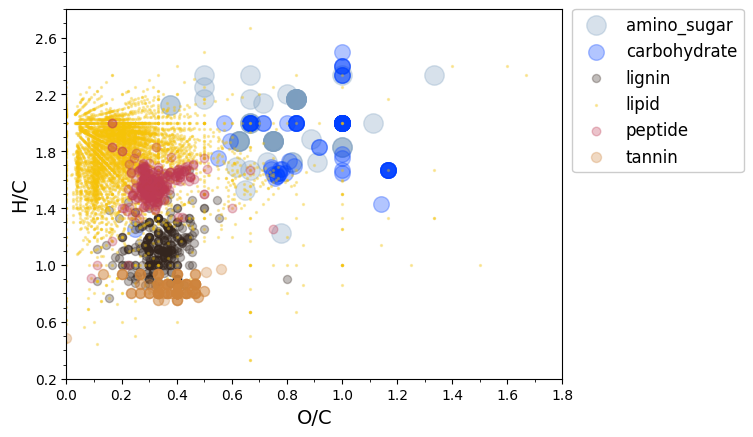

In [ ]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in df['category'].unique():
    subset = df[df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'], label=category, c = mlcf.vk_region_colours[category],
               alpha=0.3, s=1e4/len(df[df['category'] == category])) # the size of the points is inversely proportional to the number of points in that category

mlcf.set_axis_ticks(df['O/C'].values,ax,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
mlcf.set_axis_ticks(df['H/C'].values,ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)
ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)

In [ ]:
columns_2d = ['O/C','H/C']#, 'N/C', 'S/C', 'P/C']
X_2d = df[columns_2d].to_numpy()

columns_3d = ['O/C','H/C','N/C']
X_3d = df[columns_3d].to_numpy()

y = df['category'].to_numpy()
weights = df['weights'].to_numpy() if weighted else None

multiclass_colors=[mlcf.vk_region_colours[cat] for cat in np.unique(y)]

In [ ]:
# Train 2D models on the entire dataset
knn_2d = mlcf.knn_pipeline(mlcf.knn_param_2d).fit(X_2d, y)
gnb_2d = CalibratedClassifierCV(GaussianNB()).fit(X_2d, y, sample_weight=weights if weighted else None)
svm_poly_2d = CalibratedClassifierCV(SVC(kernel="poly",**mlcf.svm_poly_param_2d,probability=True)).fit(X_2d, y, sample_weight=weights if weighted else None)
svm_rbf_2d = CalibratedClassifierCV(SVC(kernel="rbf",**mlcf.svm_rbf_param_2d,probability=True)).fit(X_2d, y, sample_weight=weights if weighted else None)

In [ ]:
# Train 3D models on the entire dataset
knn_3d = mlcf.knn_pipeline(mlcf.knn_param_3d).fit(X_3d, y)
gnb_3d = CalibratedClassifierCV(GaussianNB()).fit(X_3d, y, sample_weight=weights if weighted else None)
svm_poly_3d = CalibratedClassifierCV(SVC(kernel="poly",**mlcf.svm_poly_param_3d,probability=True)).fit(X_3d, y, sample_weight=weights if weighted else None)
svm_rbf_3d = CalibratedClassifierCV(SVC(kernel="rbf",**mlcf.svm_rbf_param_3d,probability=True)).fit(X_3d, y, sample_weight=weights if weighted else None)

In [ ]:
# save the 3D models
for combo in [[knn_3d,'knn.pkl'],
              [gnb_3d,'gnb.pkl'],
              [svm_poly_3d,'svm_poly.pkl'],
              [svm_rbf_3d,'svm_rbf.pkl'],]:
    
    pickle_model(combo[0],f"{models_output_folder}\\{combo[1]}")

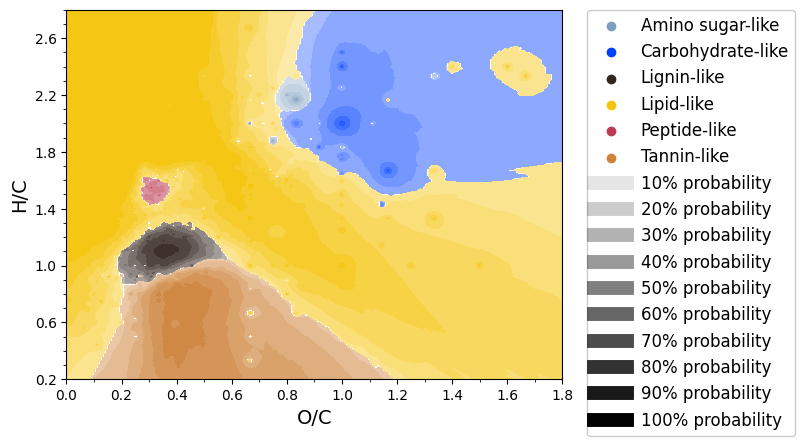

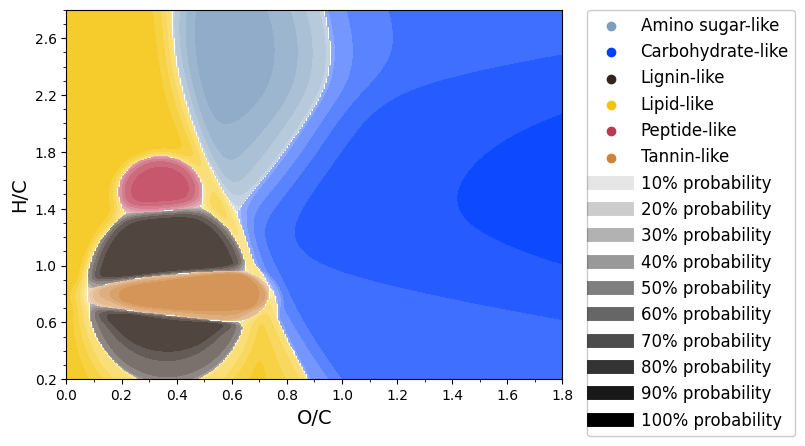

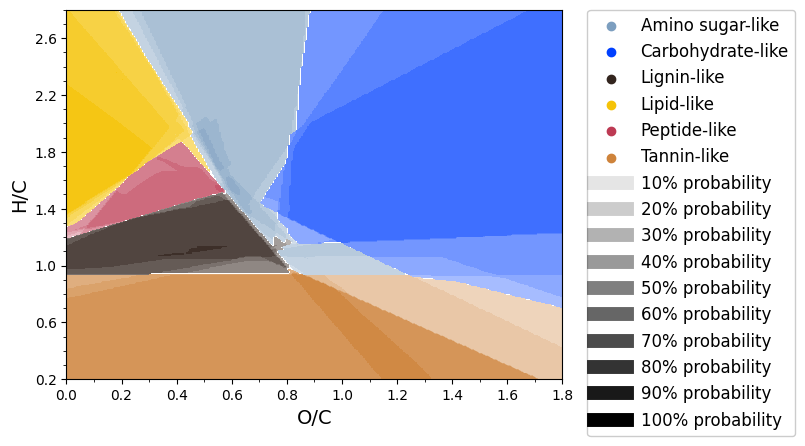

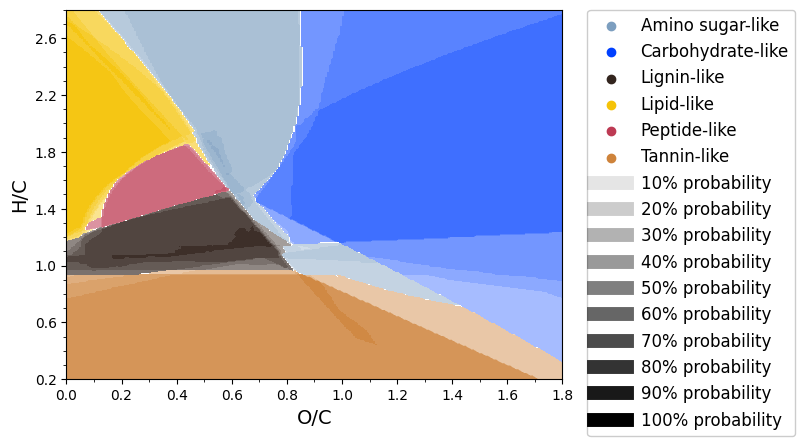

In [ ]:
# plot decision boundaries for 2D models

for combo in [[knn_2d,'$K$-Nearest Neighbours Decision Boundary\non van Krevelen Diagram','knn_vk_decision_boundary'],
              [gnb_2d,'Gaussian Naive Bayes Decision Boundary\non van Krevelen Diagram','gnb_vk_decision_boundary'],
              [svm_poly_2d,'Polynomial SVM Decision Boundary\non van Krevelen Diagram','svm_poly_vk_decision_boundary'],
              [svm_rbf_2d,'RBF SVM Decision Boundary\non van Krevelen Diagram','svm_rbf_vk_decision_boundary'],]:

    fig, ax = mlcf.draw_decision_boundary_plot(combo[0],
                                               X_2d,
                                               categories=np.unique(y),
                                               xlabel=columns_2d[0],ylabel=columns_2d[1],
                                               title=combo[1] if show_title else None,
                                               colors_dict=mlcf.vk_region_colours)
    
    mlcf.set_axis_ticks(X_2d[:,0],ax,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
    mlcf.set_axis_ticks(X_2d[:,1],ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

    fig.savefig(f'{decision_boundaries_output_folder}\\{combo[2]}.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')

In [ ]:
# plot decision boundaries for 3D models

for combo in [[knn_3d,'K-Nearest Neighbours 3D Boundary','knn_3d_vk_decision_boundary'],
              [gnb_3d,'Gaussian Naive Bayes Decision 3D Boundary','gnb_3d_vk_decision_boundary'],
              [svm_poly_3d,'Polynomial SVM Decision 3D Boundary','svm_poly_3d_vk_decision_boundary'],
              [svm_rbf_3d,'RBF SVM Decision 3D Boundary','svm_rbf_3d_vk_decision_boundary'],]:
    
        DecisionBoundaryDisplay_3D(X_3d, combo[0], dims=columns_3d,
                                   title=combo[1] if show_title else None,
                                   savepath=f'{decision_boundaries_output_folder}\\{combo[2]}.html',
                                   show=False)

## Now fit models by adding another category: PAHs.

In [ ]:
df_with_pahs = pd.read_csv(df_with_pahs_path)

for cat in df_with_pahs['category'].unique():
    print(f'# of {cat}: {len(df_with_pahs[df_with_pahs['category']==cat])} ({100*len(df_with_pahs[df_with_pahs['category']==cat])/len(df_with_pahs)})')
print(f'tot # of formulae: {len(df_with_pahs)}')

# of amino_sugar: 51 (0.8392298831660359)
# of carbohydrate: 79 (1.2999835445120949)
# of lignin: 297 (4.887279907849268)
# of lipid: 5109 (84.07108770775054)
# of pah: 86 (1.4151719598486094)
# of peptide: 263 (4.327793319071911)
# of tannin: 192 (3.159453677801547)
tot # of formulae: 6077


In [ ]:
X_with_pahs_2d = df_with_pahs[columns_2d].to_numpy()
X_with_pahs_3d = df_with_pahs[columns_3d].to_numpy()

y_with_pahs = df_with_pahs['category'].to_numpy()
weights_with_pahs = df_with_pahs['weights'].to_numpy() if weighted else None

In [ ]:
# train both classifiers with the entire dataset
knn_with_pahs_2d = mlcf.knn_pipeline(mlcf.knn_param_2d_with_PAHs).fit(X_with_pahs_2d, y_with_pahs)
gnb_with_pahs_2d = CalibratedClassifierCV(GaussianNB()).fit(X_with_pahs_2d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)
svm_poly_with_pahs_2d = CalibratedClassifierCV(SVC(kernel="poly",**mlcf.svm_poly_param_2d_with_PAHs,probability=True)).fit(X_with_pahs_2d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)
svm_rbf_with_pahs_2d = CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_2d_with_PAHs, probability=True)).fit(X_with_pahs_2d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)

In [ ]:
knn_with_pahs_3d = mlcf.knn_pipeline(mlcf.knn_param_3d_with_PAHs).fit(X_with_pahs_3d, y_with_pahs)
gnb_with_pahs_3d = CalibratedClassifierCV(GaussianNB()).fit(X_with_pahs_3d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)
svm_poly_with_pahs_3d = CalibratedClassifierCV(SVC(kernel="poly",
                                                   **mlcf.svm_poly_param_3d_with_PAHs,
                                                   probability=True)).fit(X_with_pahs_3d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)
svm_rbf_with_pahs_3d = CalibratedClassifierCV(SVC(kernel="rbf",
                                                  **mlcf.svm_rbf_param_3d_with_PAHs,
                                                  probability=True)).fit(X_with_pahs_3d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)

In [ ]:
for combo in [[knn_with_pahs_3d,'knn_with_pahs'],
              [gnb_with_pahs_3d,'gnb_with_pahs'],
              [svm_poly_with_pahs_3d,'svm_poly_with_pahs'],
              [svm_rbf_with_pahs_3d,'svm_rbf_with_pahs'],]:

    pickle_model(combo[0],f"{models_output_folder}\\{combo[1]}.pkl")

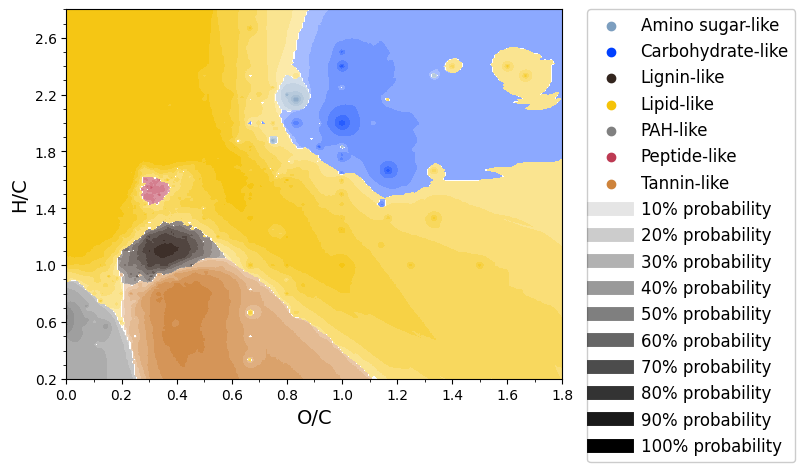

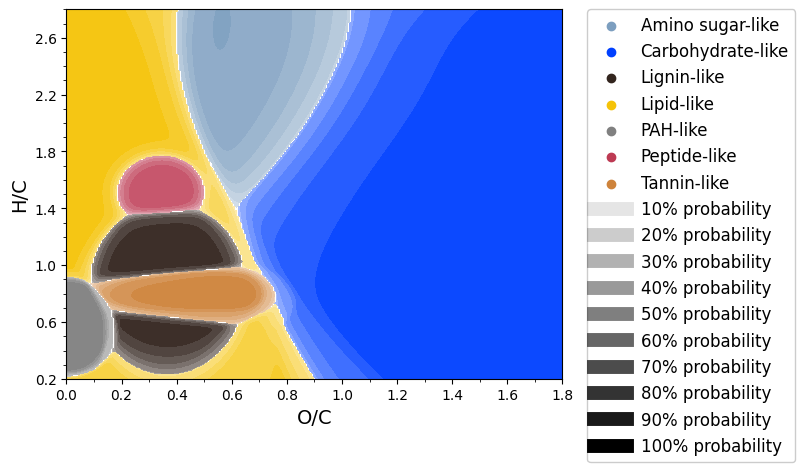

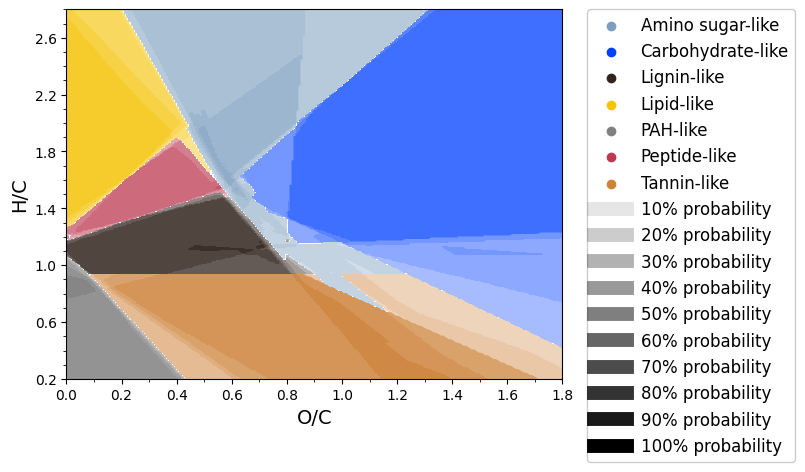

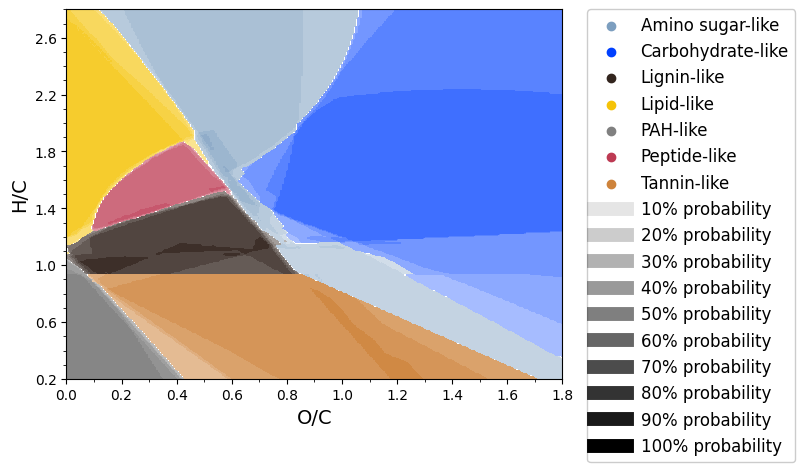

In [ ]:
for combo in [[knn_with_pahs_2d,'$K$-Nearest Neighbours Decision Boundary\non van Krevelen Diagram','knn_vk_decision_boundary_with_pahs'],
              [gnb_with_pahs_2d,'Gaussian Naive Bayes Decision Boundary\non van Krevelen Diagram','gnb_vk_decision_boundary_with_pahs'],
              [svm_poly_with_pahs_2d,f'Polynomial SVM Decision Boundary\non van Krevelen Diagram','svm_poly_vk_decision_boundary_with_pahs'],
              [svm_rbf_with_pahs_2d,'RBF SVM Decision Boundary\non van Krevelen Diagram','svm_rbf_vk_decision_boundary_with_pahs'],]:

    fig, ax = mlcf.draw_decision_boundary_plot(combo[0],
                                               X_with_pahs_2d,
                                               categories=np.unique(y_with_pahs),
                                               xlabel=columns_2d[0],
                                               ylabel=columns_2d[1],
                                               title=combo[1] if show_title else None,
                                               colors_dict=mlcf.vk_region_colours,)

    mlcf.set_axis_ticks(X_2d[:,0],ax,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
    mlcf.set_axis_ticks(X_2d[:,1],ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

    fig.savefig(f'{decision_boundaries_output_folder}\\{combo[2]}.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')

In [ ]:
for combo in [[knn_with_pahs_3d,'K-Nearest Neighbours 3D Decision Boundary\non van Krevelen Diagram','knn_3d_vk_decision_boundary_with_pahs'],
              [gnb_with_pahs_3d,'Gaussian Naive Bayes 3D Decision Boundary\non van Krevelen Diagram','gnb_3d_vk_decision_boundary_with_pahs'],
              [svm_poly_with_pahs_3d,'Polynomial SVM 3D Decision Boundary\non van Krevelen Diagram','svm_poly_3d_vk_decision_boundary_with_pahs'],
              [svm_rbf_with_pahs_3d,'RBF SVM Decision Boundary\non van Krevelen Diagram - 3D','svm_rbf_3d_vk_decision_boundary_with_pahs'],]:

    DecisionBoundaryDisplay_3D(X_with_pahs_3d,
                               combo[0],
                               dims=columns_3d,
                               title=combo[1],
                               savepath=f'{decision_boundaries_output_folder}\\{combo[2]}.html',
                               show=False,)